In [106]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import sys
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))
# Local imports
from dataloader import load_data
from model import DiabetesNN
import matplotlib.pyplot as plt

In [94]:
# ── Reproducibility ───────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ── Hyperparameters ────────────────────
LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
PATIENCE = 5

In [95]:
# ── 1. Load data ──────────────────────────────────────────────────
print("Loading data …")
X_train, X_test, y_train, y_test = load_data()

print("=" * 60)
print("                    DATA SUMMARY")
print("=" * 60)
print(f"  Training features : {X_train.shape}")
print(f"  Test features     : {X_test.shape}")
print(f"  Training labels   : {y_train.shape}  "
        f"(Diabetic: {int(y_train.sum())}, "
        f"Non-diabetic: {int(len(y_train) - y_train.sum())})")
print(f"  Test labels       : {y_test.shape}  "
        f"(Diabetic: {int(y_test.sum())}, "
        f"Non-diabetic: {int(len(y_test) - y_test.sum())})")
print("=" * 60)
print()

Loading data …
                    DATA SUMMARY
  Training features : (270, 8)
  Test features     : (68, 8)
  Training labels   : (270,)  (Diabetic: 78, Non-diabetic: 192)
  Test labels       : (68,)  (Diabetic: 20, Non-diabetic: 48)



In [96]:
# ── 2. Build model ────────────────────────────────────────────────
input_dim = X_train.shape[1]
model = DiabetesNN(input_dim=input_dim, hidden_units=[32, 16])

# Build the model so summary() works
model.build(input_shape=(None, input_dim))

print("Model Architecture:")
model.model_layers.summary()
print()

Model Architecture:


d:\Gam3a\senior 2\Deep-Learning\Assignments\neural-network-diabetes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
# ── 3. Compile ────────────────────────────────────────────────────
model.compile(
    optimizer=AdamW(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)
print("✓ Model compiled (Adam, Binary Crossentropy)\n")

✓ Model compiled (Adam, Binary Crossentropy)



In [98]:
# ── 4. Callbacks ──────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

In [99]:
# ── 5. Train ──────────────────────────────────────────────────────
print("Starting training …")
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    verbose=1,
)

Starting training …
Epoch 1/100


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - binary_accuracy: 0.3380 - loss: 0.8733 - val_binary_accuracy: 0.2222 - val_loss: 0.8598
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.3750 - loss: 0.8211 - val_binary_accuracy: 0.2407 - val_loss: 0.7980
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.4028 - loss: 0.7788 - val_binary_accuracy: 0.3519 - val_loss: 0.7483
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.4583 - loss: 0.7308 - val_binary_accuracy: 0.4444 - val_loss: 0.7065
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.5139 - loss: 0.6892 - val_binary_accuracy: 0.5370 - val_loss: 0.6711
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.6157 - loss: 0.6532 - val_binary_accuracy: 0.6667 - val_loss: 0.6414
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.6528 - loss: 0.6361 - val_binary_accuracy: 0.7407 - val_loss: 0.6167
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━

In [100]:
# ── 6. Evaluate ───────────────────────────────────────────────────
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print()
print("=" * 60)
print("                  EVALUATION RESULTS")
print("=" * 60)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f}")
print("=" * 60)


                  EVALUATION RESULTS
  Test Loss     : 0.5326
  Test Accuracy : 0.7794


Graph saved successfully to: ../results\training_curves.png


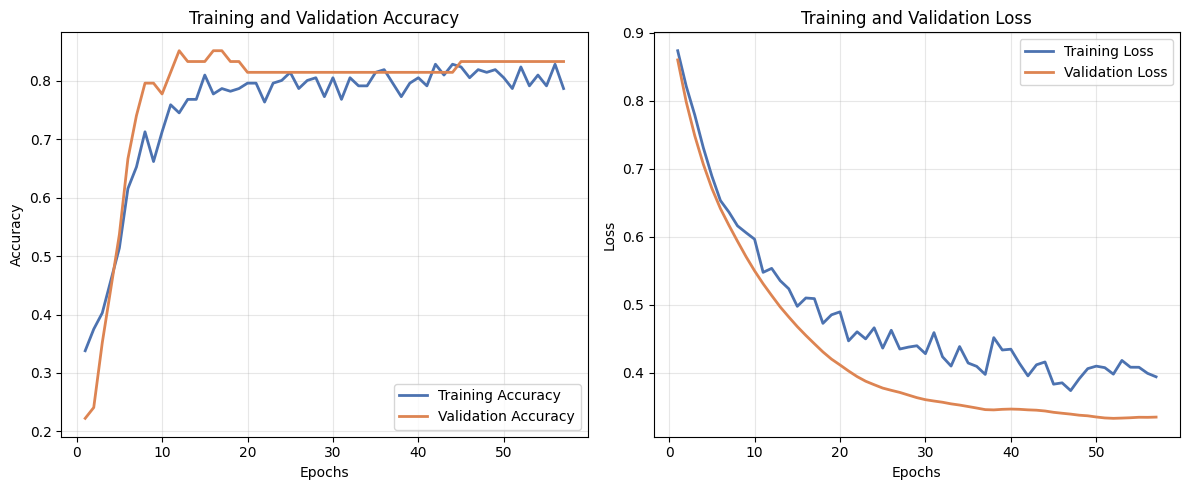

In [101]:
# ── 6. Visualize Training History ────────────────────────────────────

acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#4c72b0', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#dd8452', lw=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#4c72b0', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#dd8452', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
# Save the file
save_path = os.path.join('../results', "training_curves.png")
plt.savefig(save_path, dpi=300)
print(f"Graph saved successfully to: {save_path}")
plt.show()



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.85      0.85        48
    Diabetes       0.63      0.60      0.62        20

    accuracy                           0.78        68
   macro avg       0.73      0.73      0.73        68
weighted avg       0.78      0.78      0.78        68

Confusion matrix image saved to: ../results\confusion_matrix.png


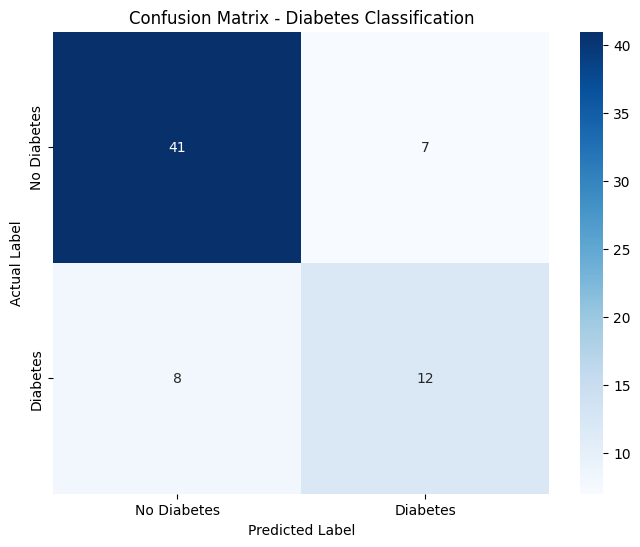

In [107]:
def evaluate_and_plot_cm(model, X_test, y_test, save_dir="../results"):
    # 1. Get predictions (probabilities)
    y_pred_probs = model.predict(X_test)
    # 2. Convert probabilities to binary classes (0 or 1)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # 3. Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Print the text-based classification report for precision/recall/f1
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

    # 4. Visualize with Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Diabetes', 'Diabetes'], 
                yticklabels=['No Diabetes', 'Diabetes'])
    
    plt.title('Confusion Matrix - Diabetes Classification')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    
    # Save the figure
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    save_path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix image saved to: {save_path}")
    
    plt.show()

# Call after model evaluation
evaluate_and_plot_cm(model, X_test, y_test)

In [108]:
def save_metrics_summary(model, X_test, y_test, save_dir="../results"):
    # 1. Get predictions
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # 2. Calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_probs)

    # 3. Create formatted summary string
    summary_text = (
        "Classification Metrics Summary\n"
        "==============================\n"
        f"Accuracy:  {accuracy:.4f}\n"
        f"Precision: {precision:.4f}\n"
        f"Recall:    {recall:.4f} (Sensitivity)\n"
        f"F1-Score:  {f1:.4f}\n"
        f"ROC AUC:   {auc:.4f}\n"
        "==============================\n"
        "Note: Recall (Sensitivity) is prioritized to minimize False Negatives."
    )

    # 4. Print to console
    print("\n" + summary_text)

    # 5. Save to file
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    file_path = os.path.join(save_dir, "metrics_summary.txt")
    with open(file_path, "w") as f:
        f.write(summary_text)
    
    print(f"Metrics summary saved to: {file_path}")

# Call this at the very end of your script
save_metrics_summary(model, X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Classification Metrics Summary
Accuracy:  0.7794
Precision: 0.6316
Recall:    0.6000 (Sensitivity)
F1-Score:  0.6154
ROC AUC:   0.7771
Note: Recall (Sensitivity) is prioritized to minimize False Negatives.
Metrics summary saved to: ../results\metrics_summary.txt
